# Import Modules

In [1]:
from matplotlib.pyplot import *
from pandas            import *
from seaborn           import *

# Setup Seaborn

In [2]:
set()

# Si01 Level

## Load Xstar Data

In [3]:
Si01_Level_xstar = read_csv("/Users/tanimoto/github/atomicdatabase/xstar_database/Si/Si01_Level.tsv",sep="\t")
Si01_Level_xstar = Si01_Level_xstar.drop(columns="Unnamed: 0")
Si01_Level_xstar

,Z,Ion,Electron,Level,N,L,2S+1,2J+1,Energy,Potential,Configuration
0,14,105,1,1,1,0,2,2,0.000,2673.00,1s1.2S_1/2
1,14,105,1,2,2,1,2,2,2004.328,2673.00,1s0.2p1.2P_1/2
2,14,105,1,3,2,1,2,4,2006.082,2673.00,1s0.2p1.2P_3/2
3,14,105,1,4,2,0,2,2,2004.393,2673.00,1s0.2s1.2S_1/2
4,14,105,1,5,3,1,2,2,2376.108,2673.00,1s0.3p1.2P_1/2
5,14,105,1,6,3,1,2,4,2376.628,2673.00,1s0.3p1.2P_3/2
6,14,105,1,7,3,0,2,2,2376.128,2673.00,1s0.3s1.2S_1/2
7,14,105,1,8,3,2,2,4,2376.627,2673.00,1s0.3d1.2D_3/2
8,14,105,1,9,3,2,2,6,2376.800,2673.00,1s0.3d1.2D_5/2
9,14,105,1,10,4,1,2,2,2506.160,2673.00,1s0.4p1.2P_1/2


## Load Monaco Data

In [4]:
Electron         = []
Level            = []
Ionized          = []
Energy           = []
Parity           = []
NL               = []
J                = []
Configuration    = []
Si01_Translation = {}

with open("/Users/tanimoto/github/atomicdatabase/monaco_database/Si/Si01.en") as file:
    for line in file.readlines():
        line = line.split()
        for n in range(len(Si01_Level_xstar.index)-1):
            if line[5]==str(100*Si01_Level_xstar["N"][n]+Si01_Level_xstar["L"][n]) and line[6]==str(Si01_Level_xstar["2J+1"][n]-1):
                Electron                 += [line[0]]
                Level                    += [Si01_Level_xstar["Level"][n]]
                Ionized                  += [line[2]]
                Energy                   += [float(line[3])]
                Parity                   += [line[4]]
                NL                       += [line[5]]
                J                        += [line[6]]
                Configuration            += [" ".join(line[7:])]
                Si01_Translation[line[1]] = str(Si01_Level_xstar["Level"][n])

Si01_Level_monaco = DataFrame({"Electron":Electron, "Level":Level, "Ionized":Ionized, "Energy":Energy, "Parity":Parity, "NL":NL, "2J":J, "Configuration":Configuration})
Si01_Level_monaco = Si01_Level_monaco.sort_values(["Level"]).reset_index(drop=True)
Si01_Level_monaco

,Electron,Level,Ionized,Energy,Parity,NL,2J,Configuration
0,1,1,-1,0.00000,0,100,1,1*1 1s1 1s+1(1)1
1,1,2,-1,2004.34588,1,201,1,2*1 2p1 2p-1(1)1
2,1,3,-1,2006.10069,1,201,3,2*1 2p1 2p+1(3)3
3,1,4,-1,2004.40893,0,200,1,2*1 2s1 2s+1(1)1
4,1,5,-1,2376.12663,1,301,1,3*1 3p1 3p-1(1)1
5,1,6,-1,2376.64668,1,301,3,3*1 3p1 3p+1(3)3
6,1,7,-1,2376.14551,0,300,1,3*1 3s1 3s+1(1)1
7,1,8,-1,2376.64578,0,302,3,3*1 3d1 3d-1(3)3
8,1,9,-1,2376.81810,0,302,5,3*1 3d1 3d+1(5)5
9,1,10,-1,2506.17845,1,401,1,4*1 4p1 4p-1(1)1


## Match Database

In [5]:
Si01_Level_Index  = []
Si01_Level_Energy = []

for i in range(len(Si01_Level_xstar.index)):
    for j in range(len(Si01_Level_monaco.index)):
        if Si01_Level_xstar["Level"][i]==Si01_Level_monaco["Level"][j]:
            Si01_Level_Index.append(Si01_Level_xstar["Level"][i])
            Si01_Level_Energy.append(Si01_Level_xstar["Energy"][i]-Si01_Level_monaco["Energy"][j])

## Plot Result

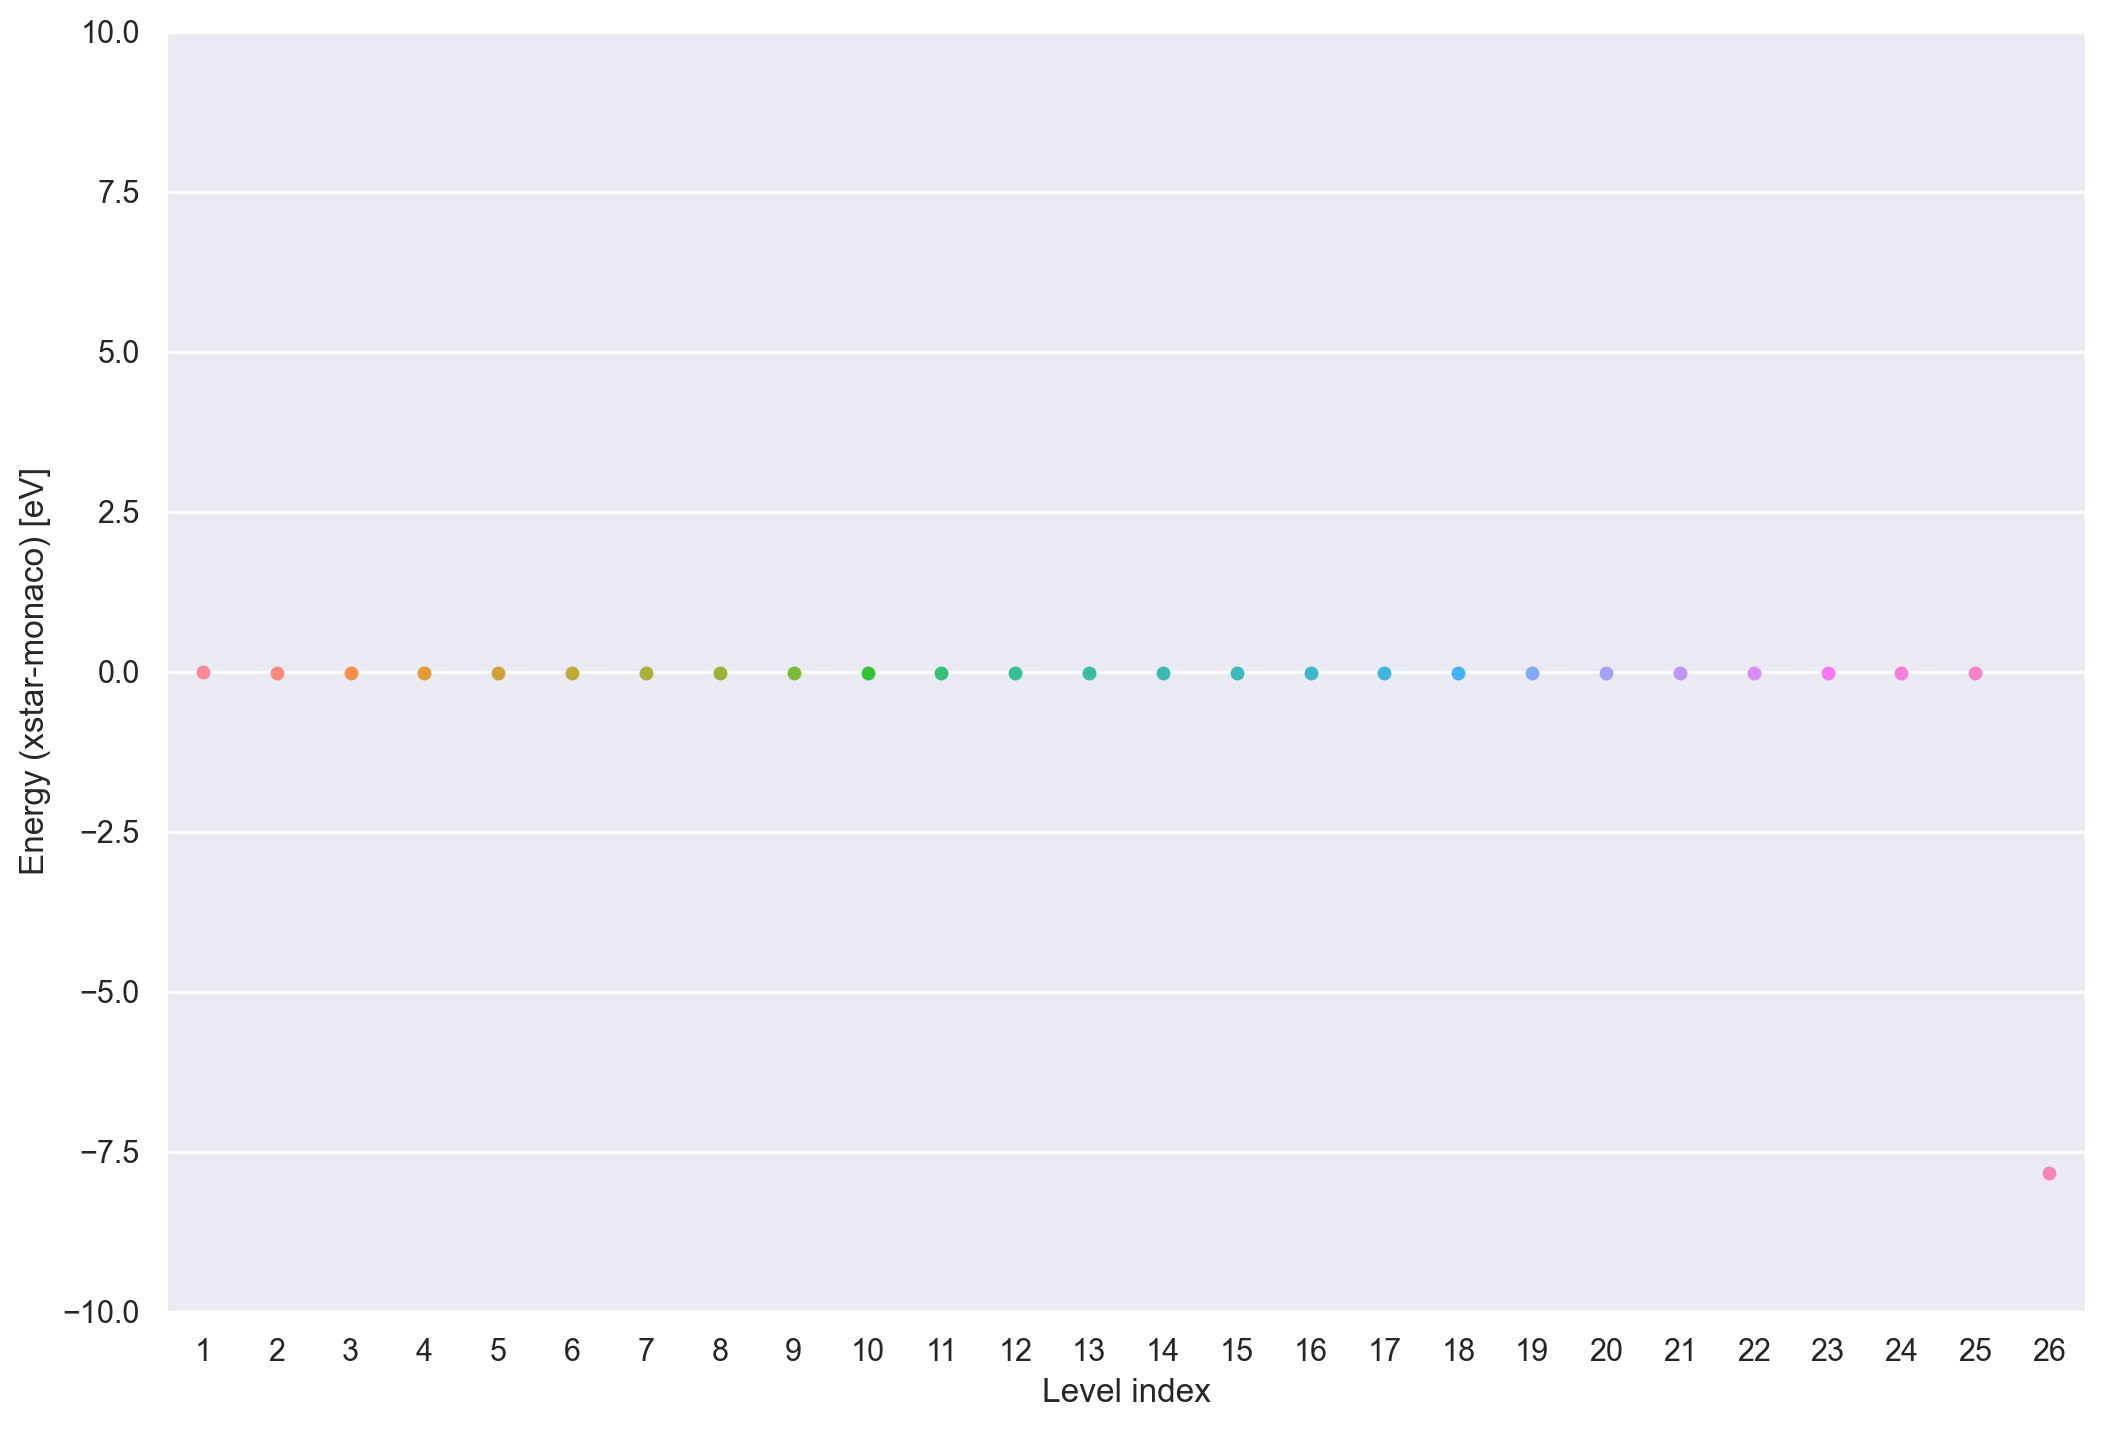

In [6]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.95)
axis           ([0e+0,3e+1,-1e+1,+1e+1])
swarmplot      (x=Si01_Level_Index, y=Si01_Level_Energy)
xlabel         ("Level index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("./figure/00.png")

# Si01 Transition

## Load Xstar Data

In [7]:
Si01_Transition_xstar = read_csv("/Users/tanimoto/github/atomicdatabase/xstar_database/Si/Si01_Transition.tsv",sep="\t")
Si01_Transition_xstar = Si01_Transition_xstar.drop(columns="Unnamed: 0")
Si01_Transition_xstar

,Z,Ion,Initial Level,Final Level,Energy,Oscillator Strength,A Coefficient
0,14,105,2,1,2004.25900,0.0,2.406770e+13
1,14,105,3,1,2006.01400,0.0,2.406770e+13
2,14,105,5,1,2376.02700,0.0,6.425310e+12
3,14,105,5,4,371.70220,0.0,8.623930e+11
4,14,105,6,1,2376.54700,0.0,6.425310e+12
...,...,...,...,...,...,...,...
128,14,105,30,16,84.67897,0.0,5.273790e+10
129,14,105,30,22,24.69472,0.0,4.247730e+10
130,14,105,30,23,24.67612,0.0,4.247730e+10
131,14,105,31,24,24.67612,0.0,6.318930e+10


## Load Monaco Data

In [8]:
Initial_Level        = []
Initial_Level_Weight = []
Final_Level          = []
Final_Level_Weight   = []
Energy               = []
Strength             = []
Rate                 = []

with open("/Users/tanimoto/github/atomicdatabase/monaco_database/Si/Si01.tr") as file:
    for line in file.readlines():
        line = line.split()
        if line[0] in Si01_Translation.keys() and line[2] in Si01_Translation.values():
            Initial_Level += [int(Si01_Translation[line[0]])]
            Final_Level   += [int(Si01_Translation[line[2]])]
            Energy        += [float(line[4])]
            Strength      += [float(line[5])]
            Rate          += [float(line[6])]

Si01_Transition_monaco = DataFrame({"Initial Level":Initial_Level, "Final Level":Final_Level, "Energy":Energy, "Strength":Strength, "Rate":Rate})
Si01_Transition_monaco = Si01_Transition_monaco.sort_values(["Initial Level", "Final Level"]).reset_index(drop=True)
Si01_Transition_monaco

,Initial Level,Final Level,Energy,Strength,Rate
0,3,2,1.754814,3.810633e-07,2.545883e+01
1,3,4,1.691762,3.793102e-03,2.355334e+05
2,4,2,0.063051,7.031455e-05,1.212951e+01
3,5,4,371.717700,1.448457e-01,8.684433e+11
4,6,4,372.237800,2.864270e-01,8.610614e+11
...,...,...,...,...,...
90,26,6,222.365900,3.097575e-03,1.329223e+10
91,26,10,92.834170,1.232942e-02,4.610709e+09
92,26,11,92.614830,1.259604e-02,9.376359e+09
93,26,17,32.669240,7.448735e-02,3.449610e+09


## Match Database

In [9]:
Si01_Transition_Index    = []
Si01_Transition_Energy   = []
Si01_Transition_Strength = []
Si01_Transition_Rate     = []

for i in range(len(Si01_Transition_xstar.index)):
    for j in range(len(Si01_Transition_monaco.index)):
        if Si01_Transition_xstar["Initial Level"][i]==Si01_Transition_monaco["Initial Level"][j] and Si01_Transition_xstar["Final Level"][i]==Si01_Transition_monaco["Final Level"][j]:
            Si01_Transition_Index.append(100*Si01_Transition_xstar["Initial Level"][i]+Si01_Transition_xstar["Final Level"][i])
            Si01_Transition_Energy.append(Si01_Transition_xstar["Energy"][i]-Si01_Transition_monaco["Energy"][j])
            Si01_Transition_Strength.append(Si01_Transition_xstar["Strength"][i]-Si01_Transition_monaco["Strength"][j])
            Si01_Transition_Rate.append(Si01_Transition_xstar["Rate"][i]-Si01_Transition_monaco["Rate"][j])

KeyError: 'Strength'

## Plot Energy

Text(0, 0.5, 'Energy (xstar-monaco) [eV]')

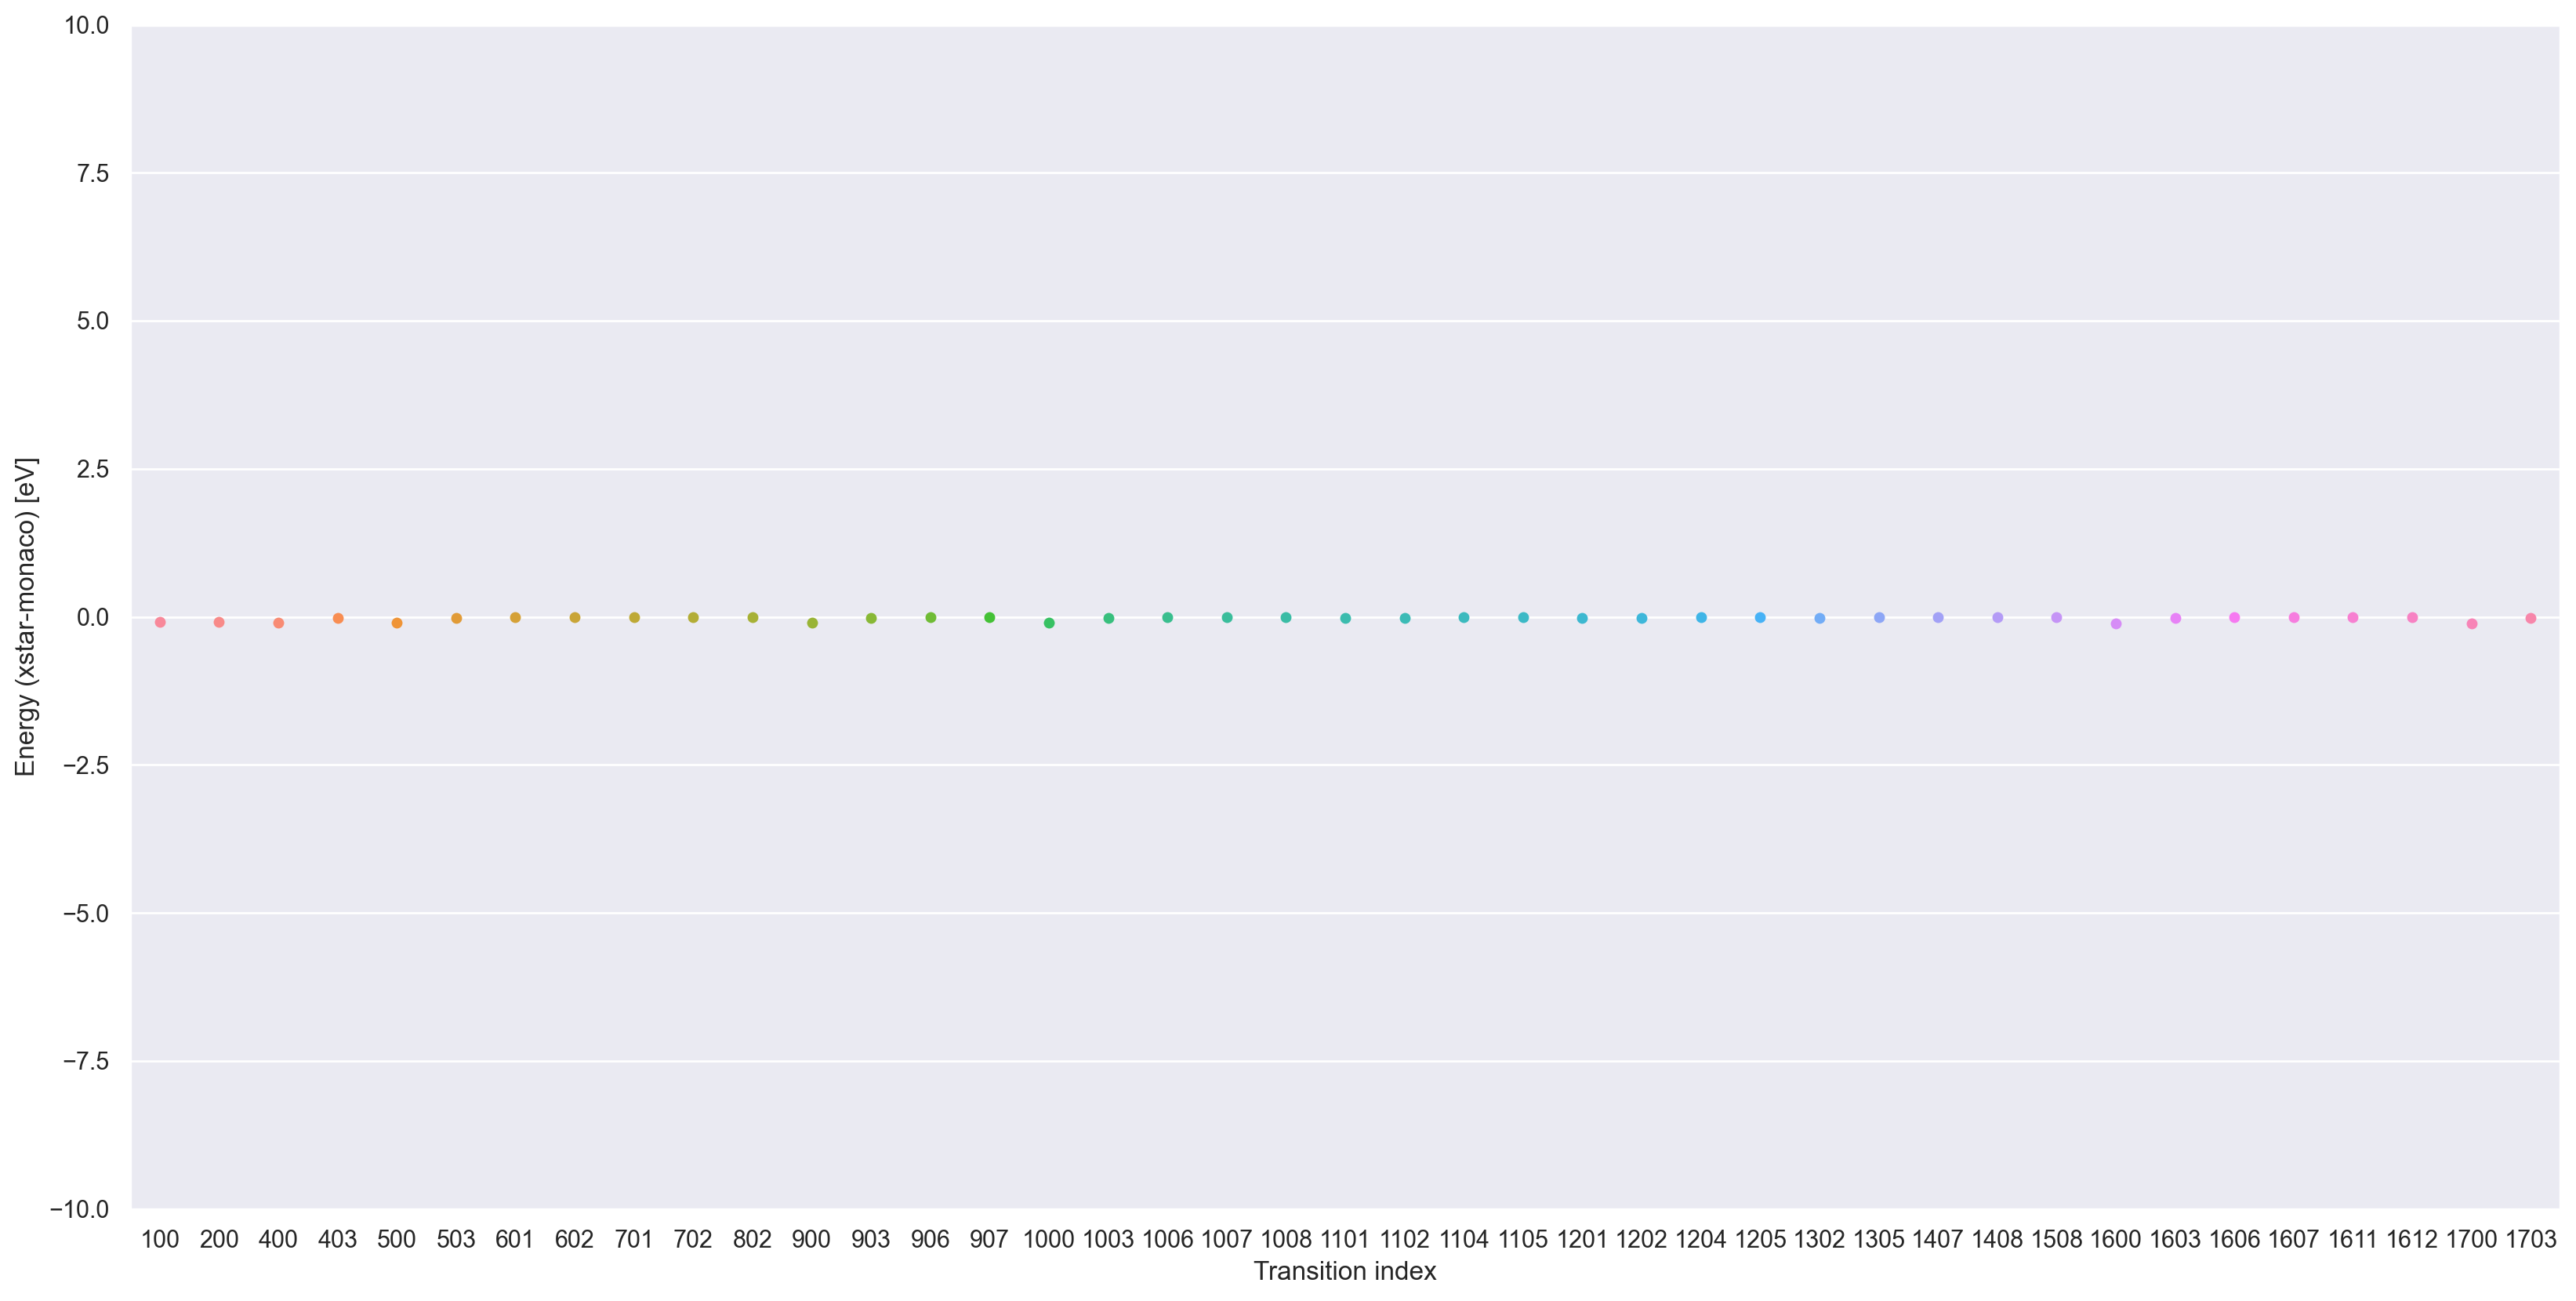

In [18]:
fi = figure(figsize=(20,10),dpi=200)
axis       ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot  (x=Si01_Transition_Index[:41], y=Si01_Transition_Energy[:41])
xlabel     ("Transition index")
ylabel     ("Energy (xstar-monaco) [eV]")

Text(0, 0.5, 'Energy (xstar-monaco) [eV]')

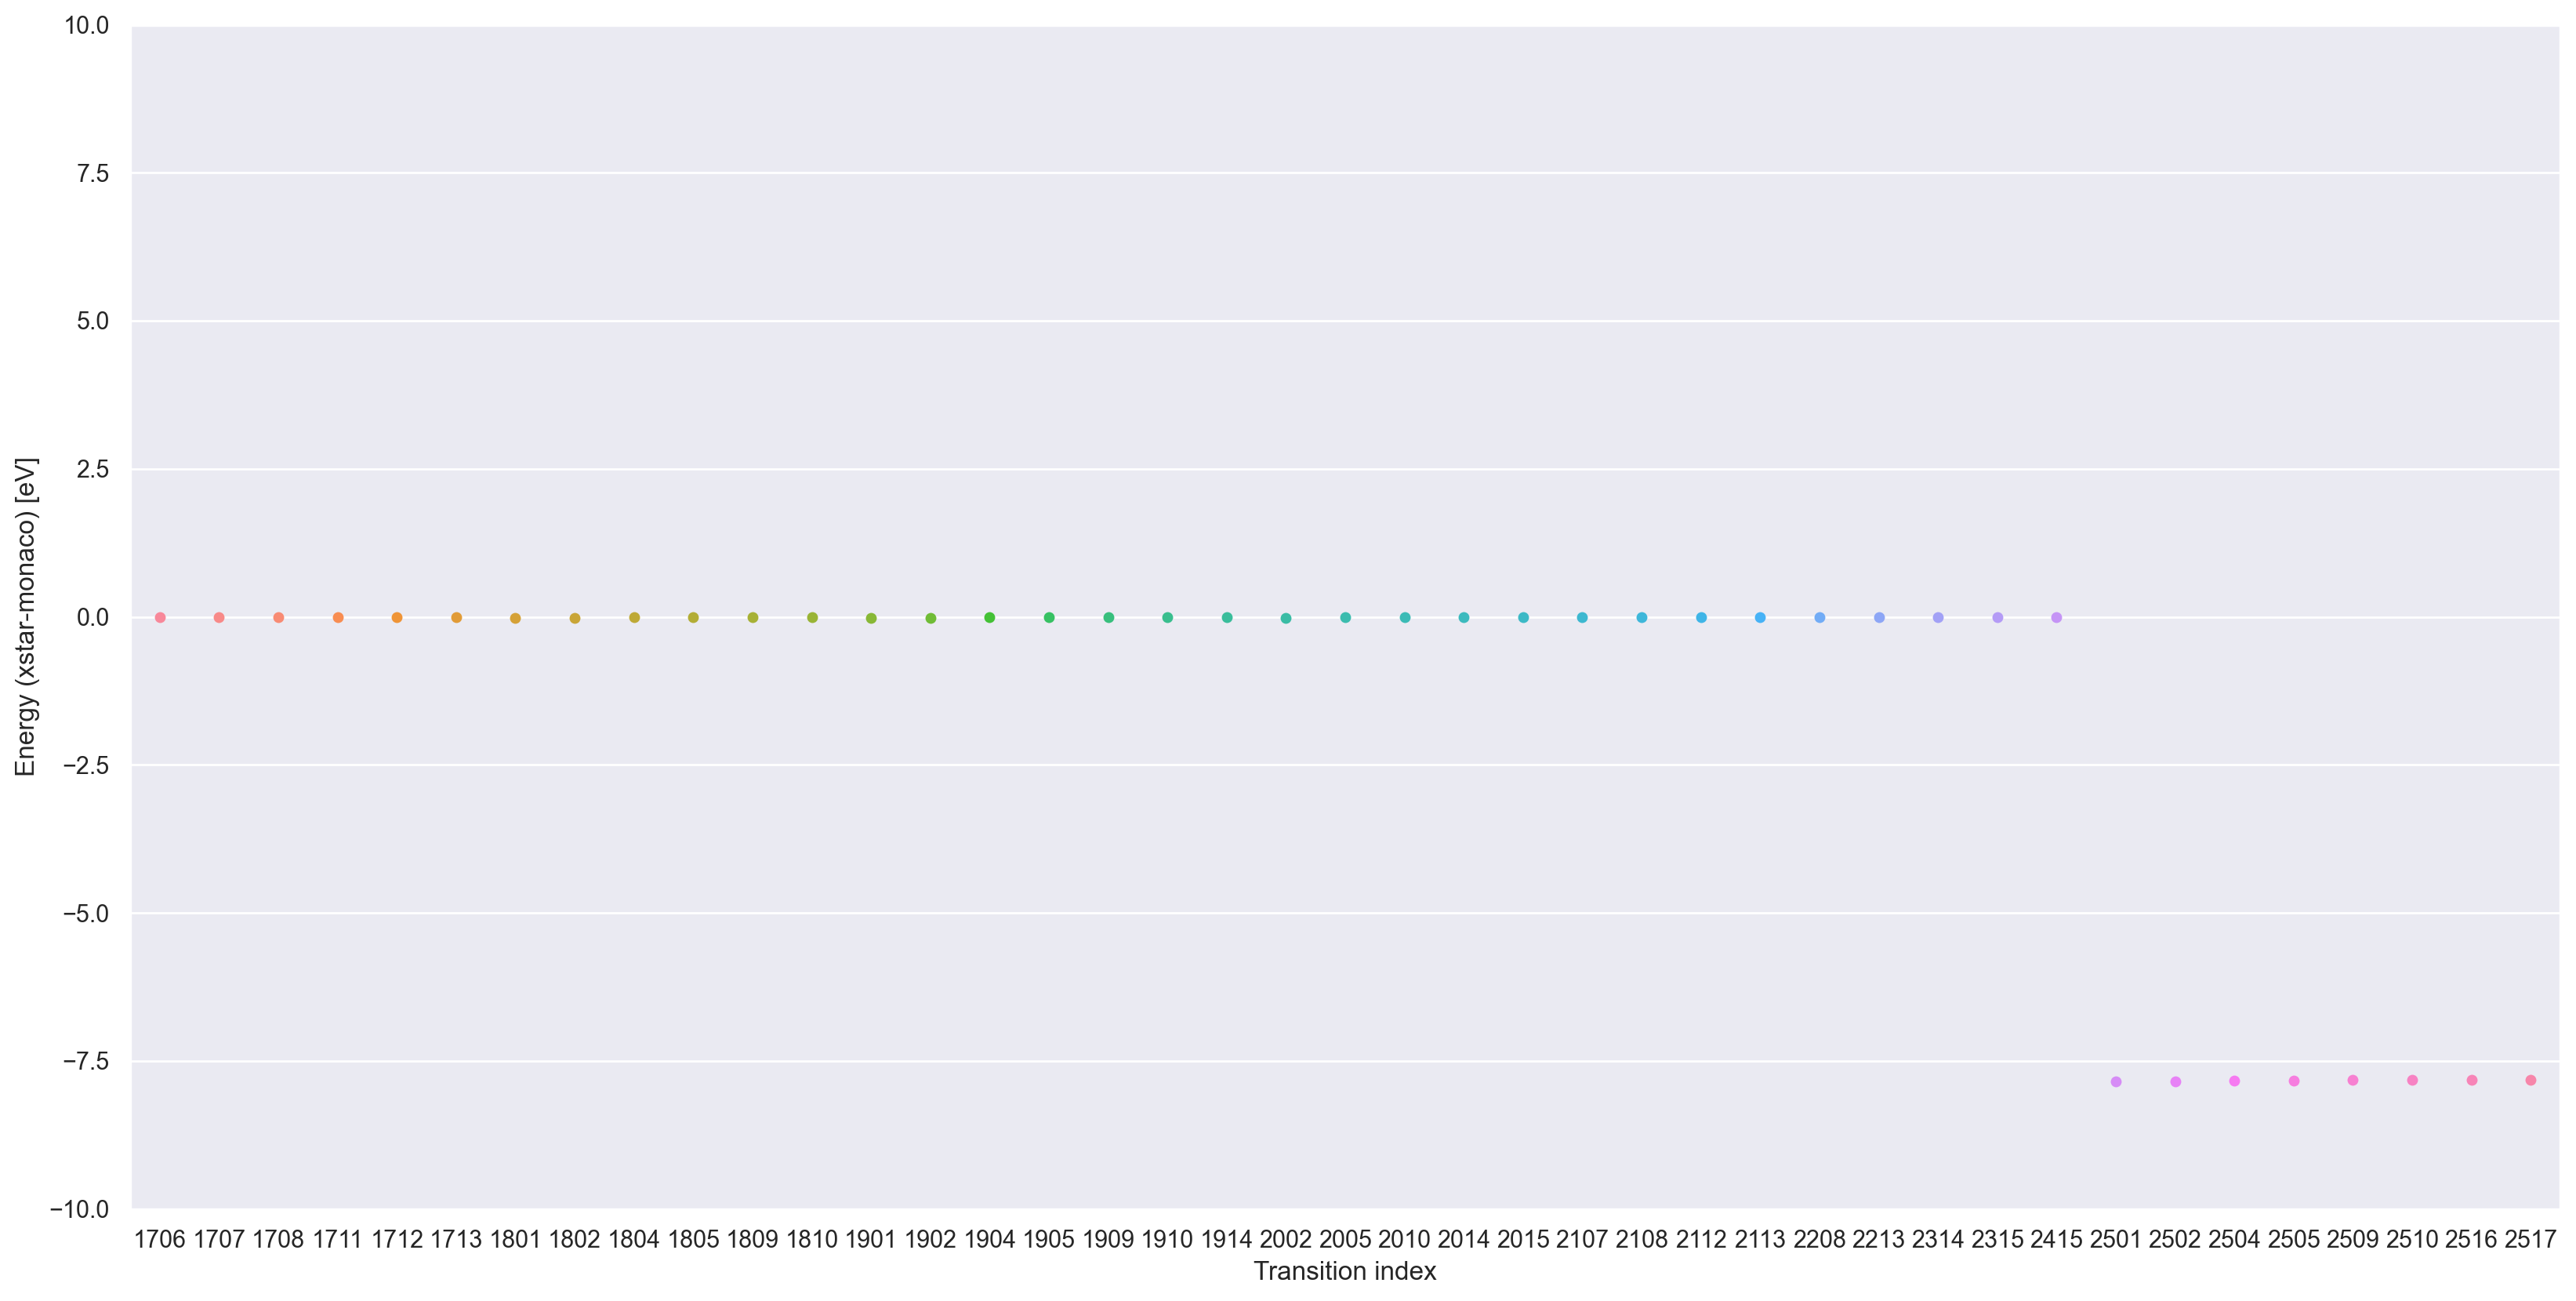

In [19]:
fi = figure(figsize=(20,10),dpi=200)
axis       ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot  (x=Si01_Transition_Index[41:], y=Si01_Transition_Energy[41:])
xlabel     ("Transition index")
ylabel     ("Energy (xstar-monaco) [eV]")

## Plot Strength

Text(0, 0.5, 'Strength (xstar-monaco)')

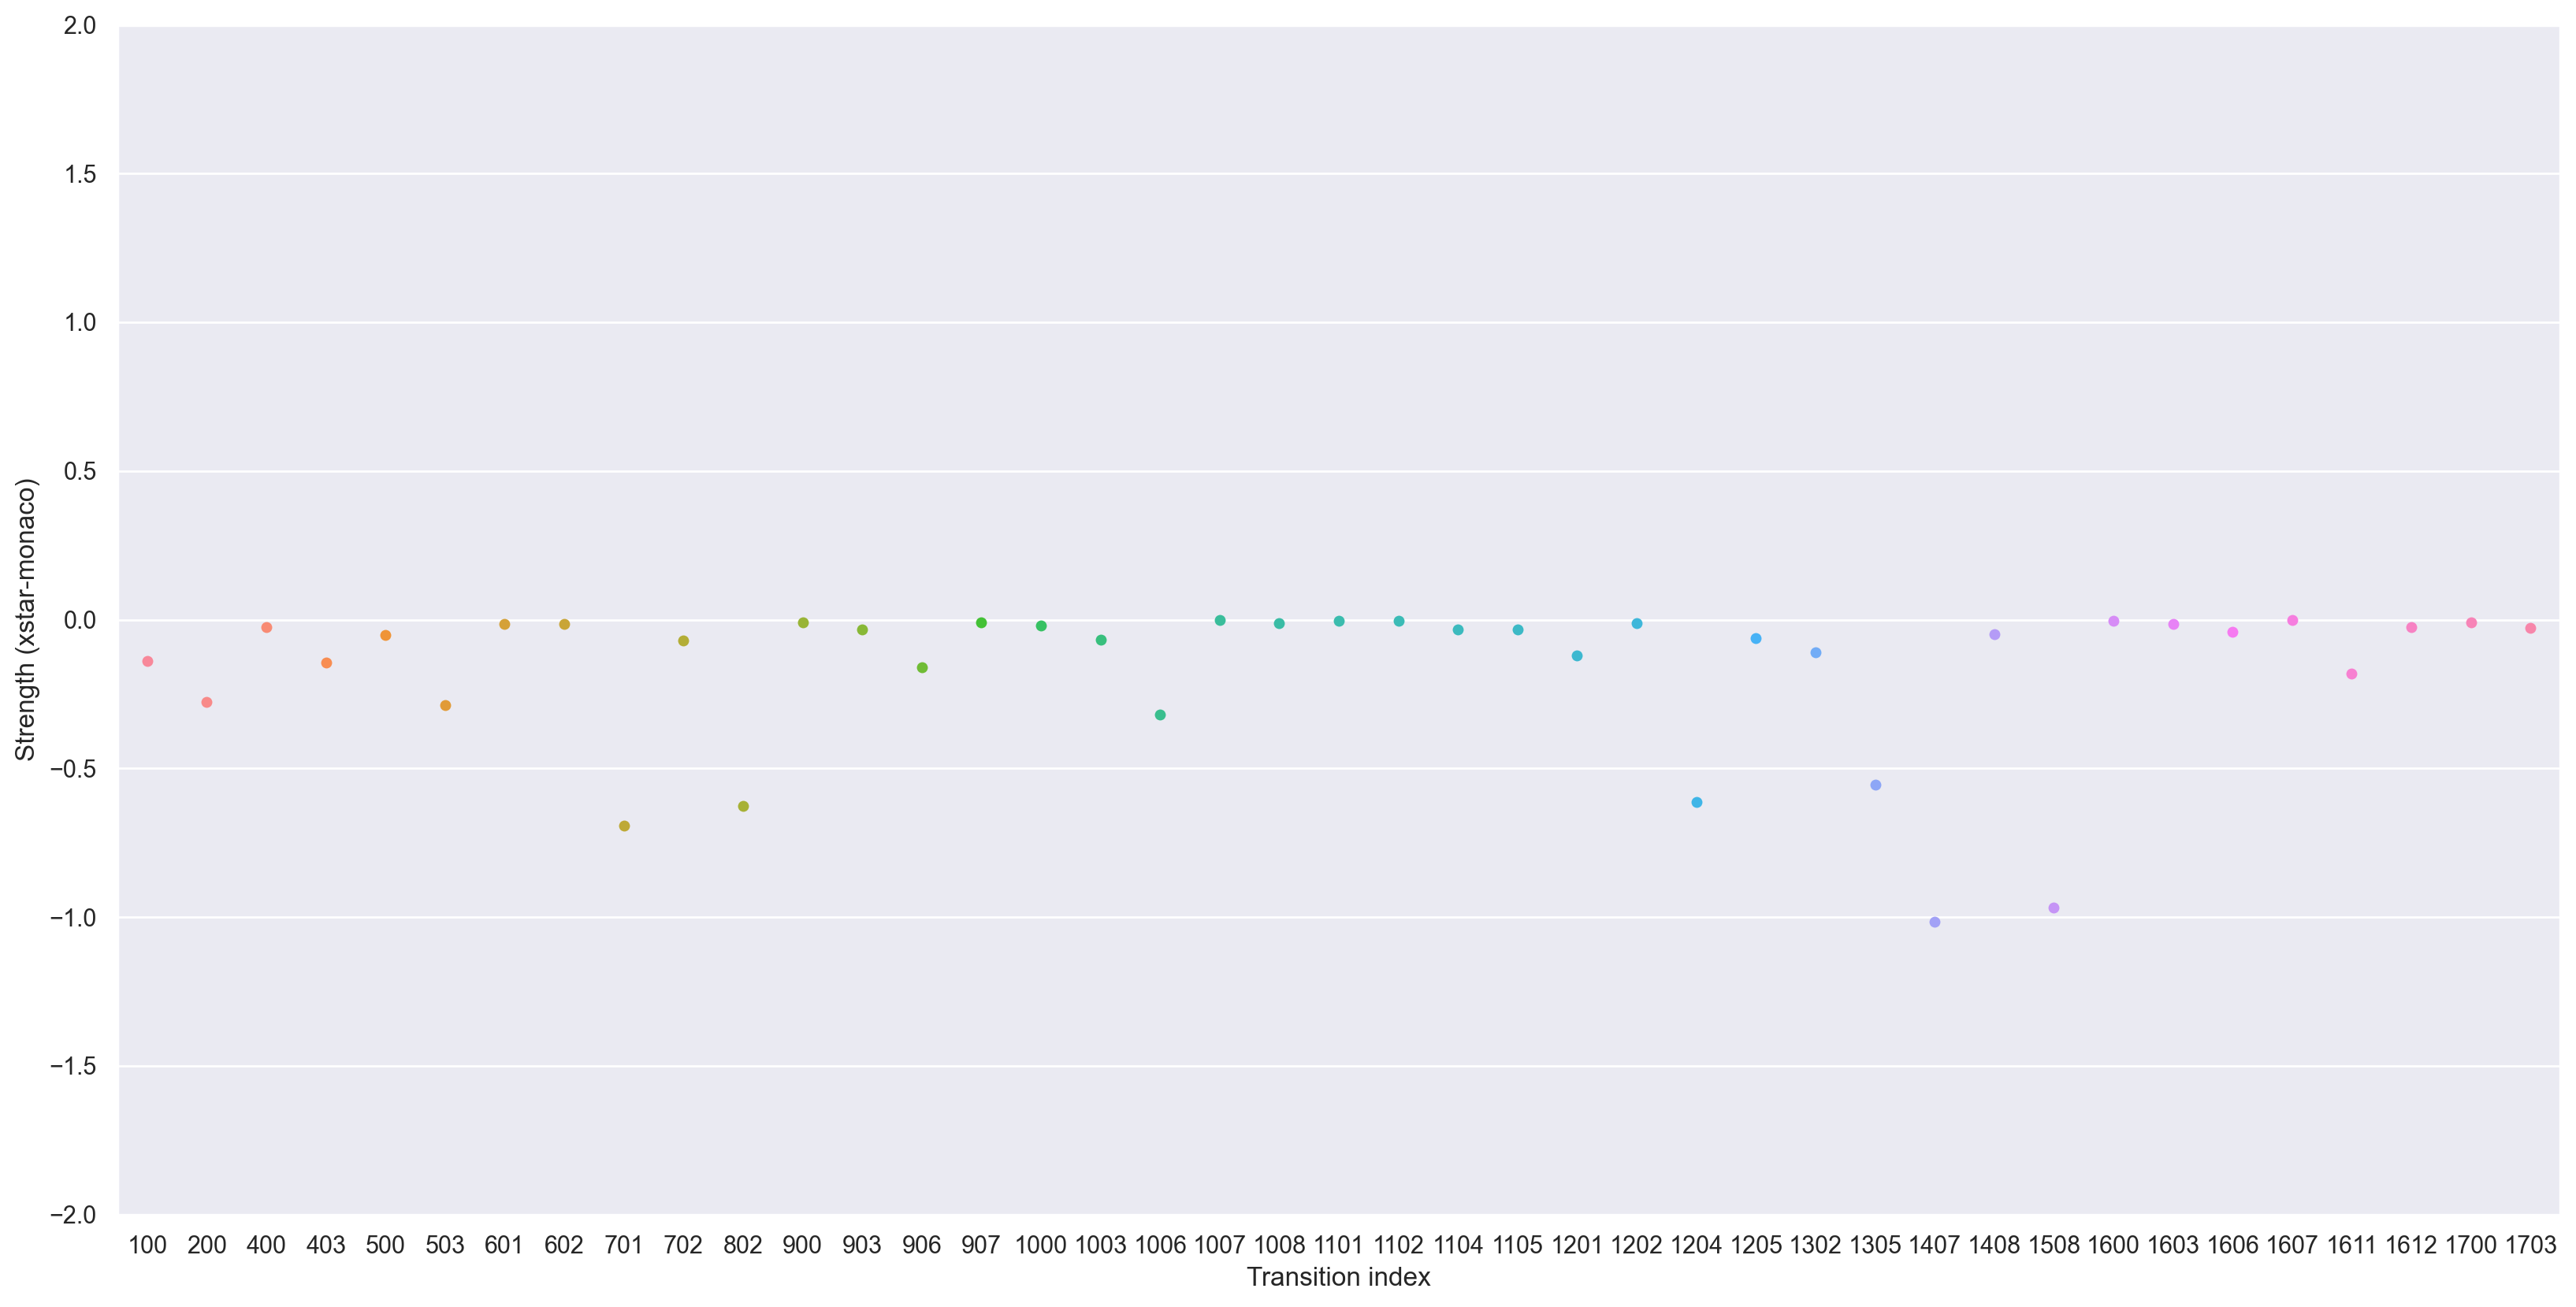

In [20]:
fi = figure(figsize=(20,10),dpi=200)
axis       ([0e+0,3e+3,-2e+0,+2e+0])
swarmplot  (x=Si01_Transition_Index[:41], y=Si01_Transition_Strength[:41])
xlabel     ("Transition index")
ylabel     ("Strength (xstar-monaco)")

Text(0, 0.5, 'Strength (xstar-monaco)')

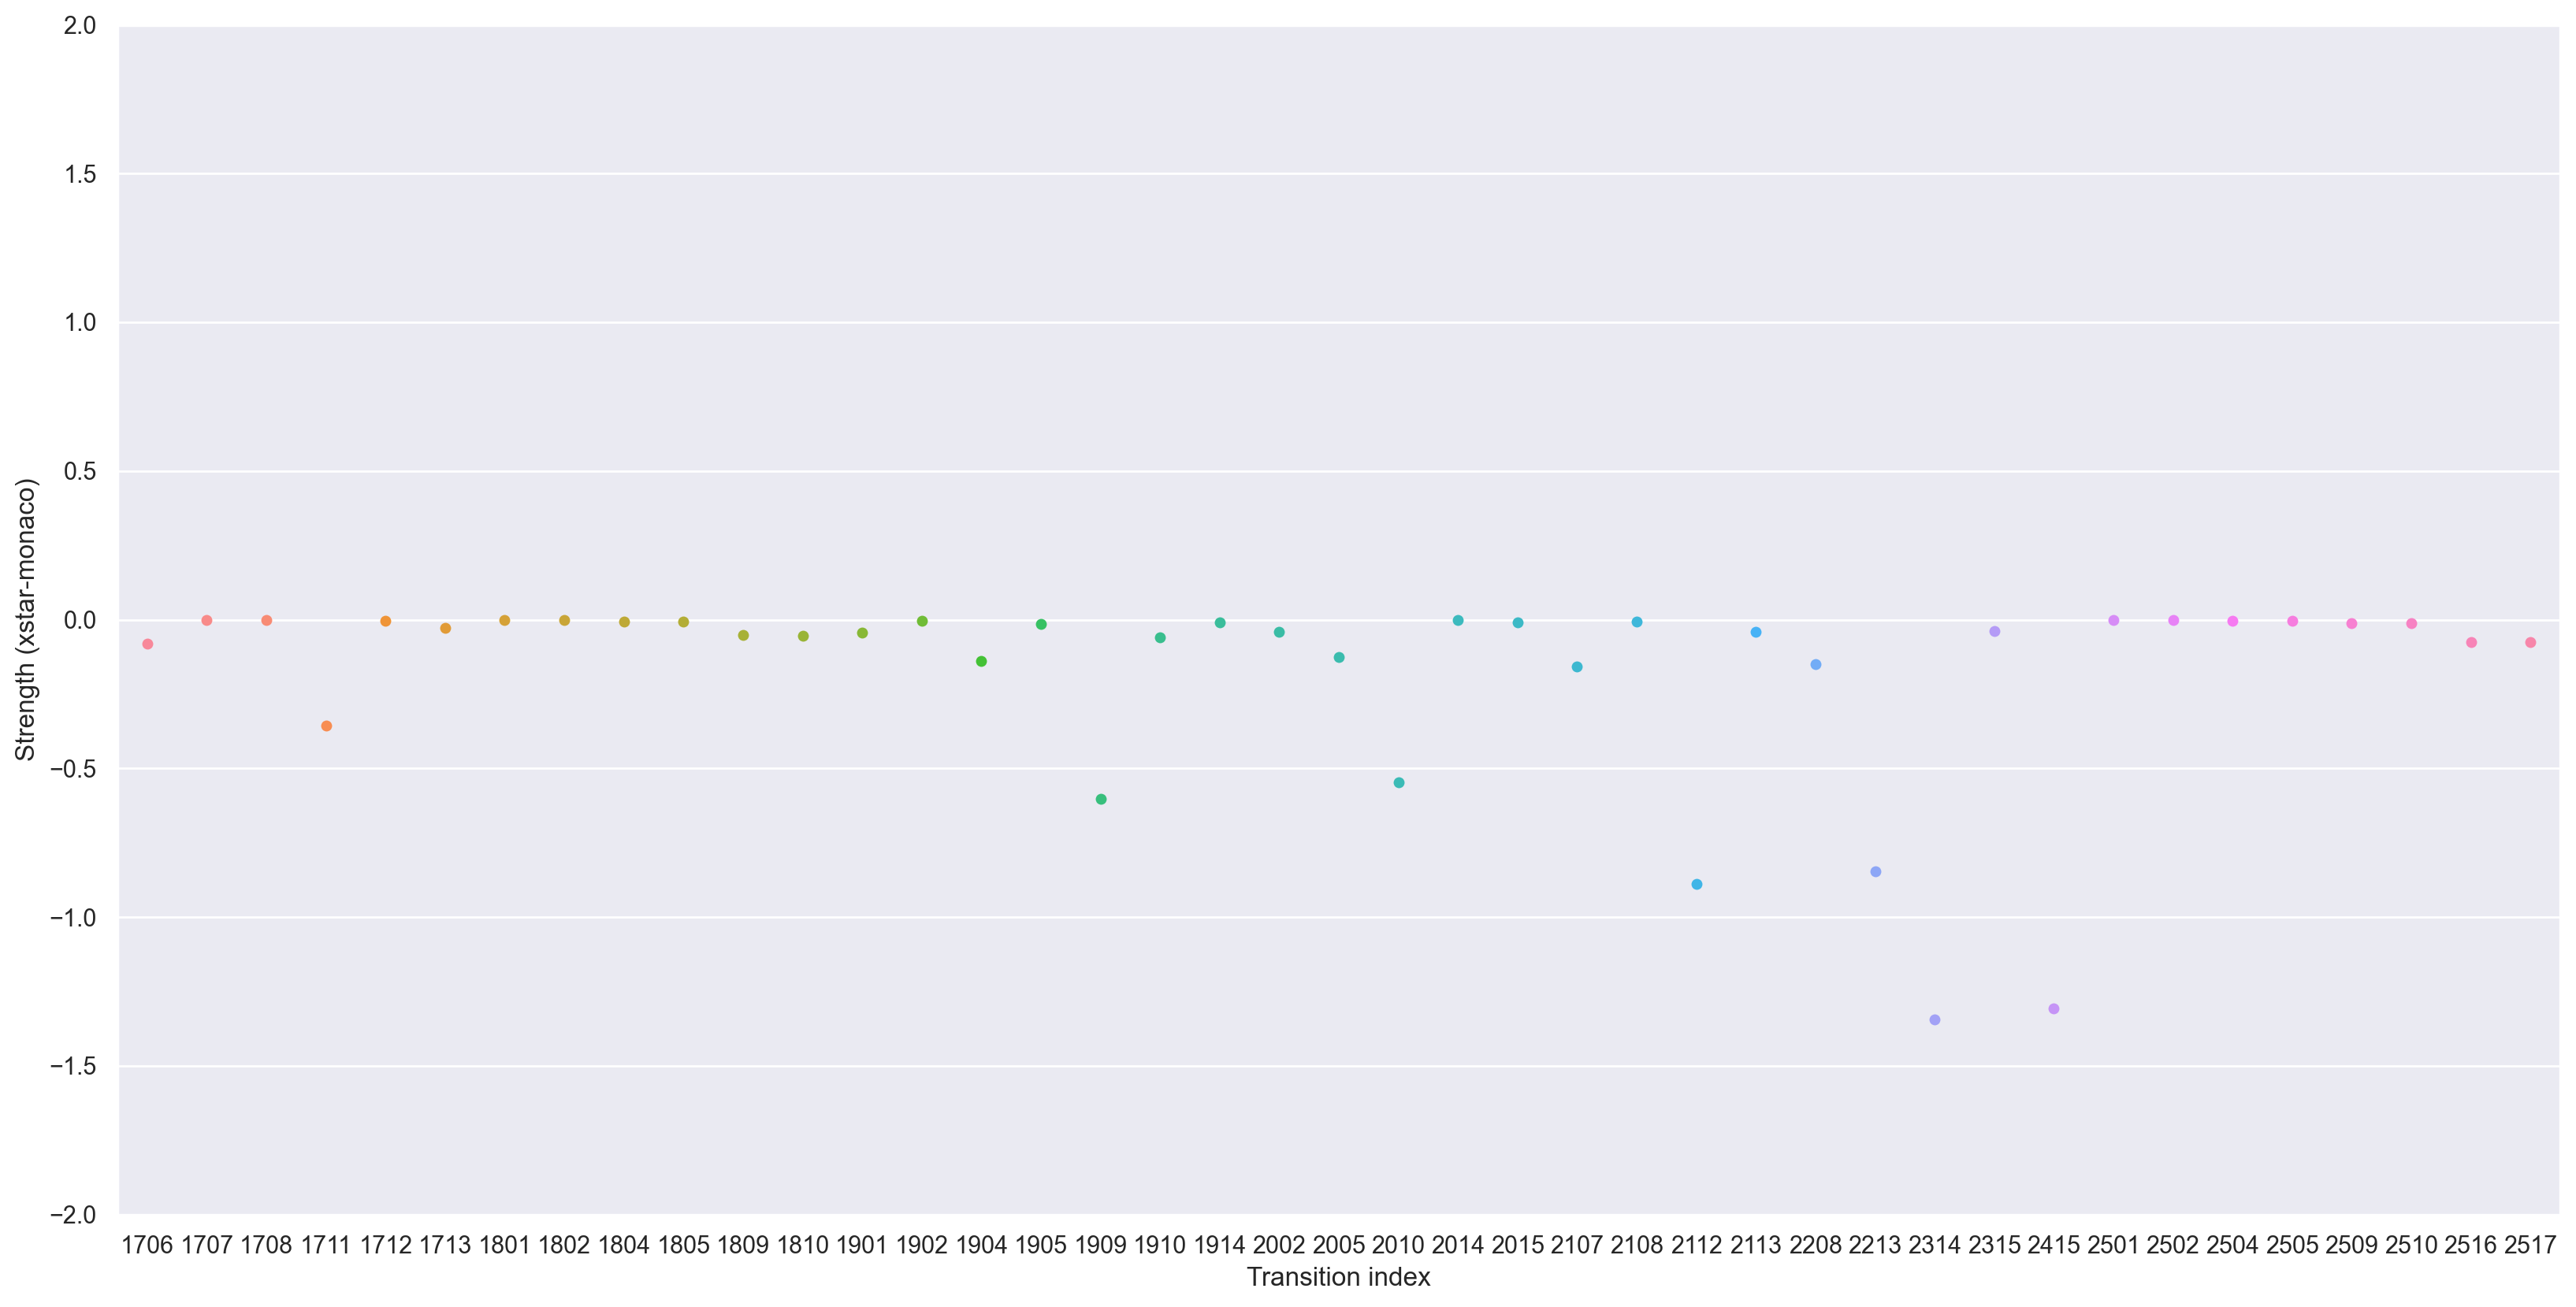

In [21]:
fi = figure(figsize=(20,10),dpi=200)
axis       ([0e+0,3e+3,-2e+0,+2e+0])
swarmplot  (x=Si01_Transition_Index[41:], y=Si01_Transition_Strength[41:])
xlabel     ("Transition index")
ylabel     ("Strength (xstar-monaco)")

## Plot Rate

Text(0, 0.5, 'Rate (xstar-monaco)')

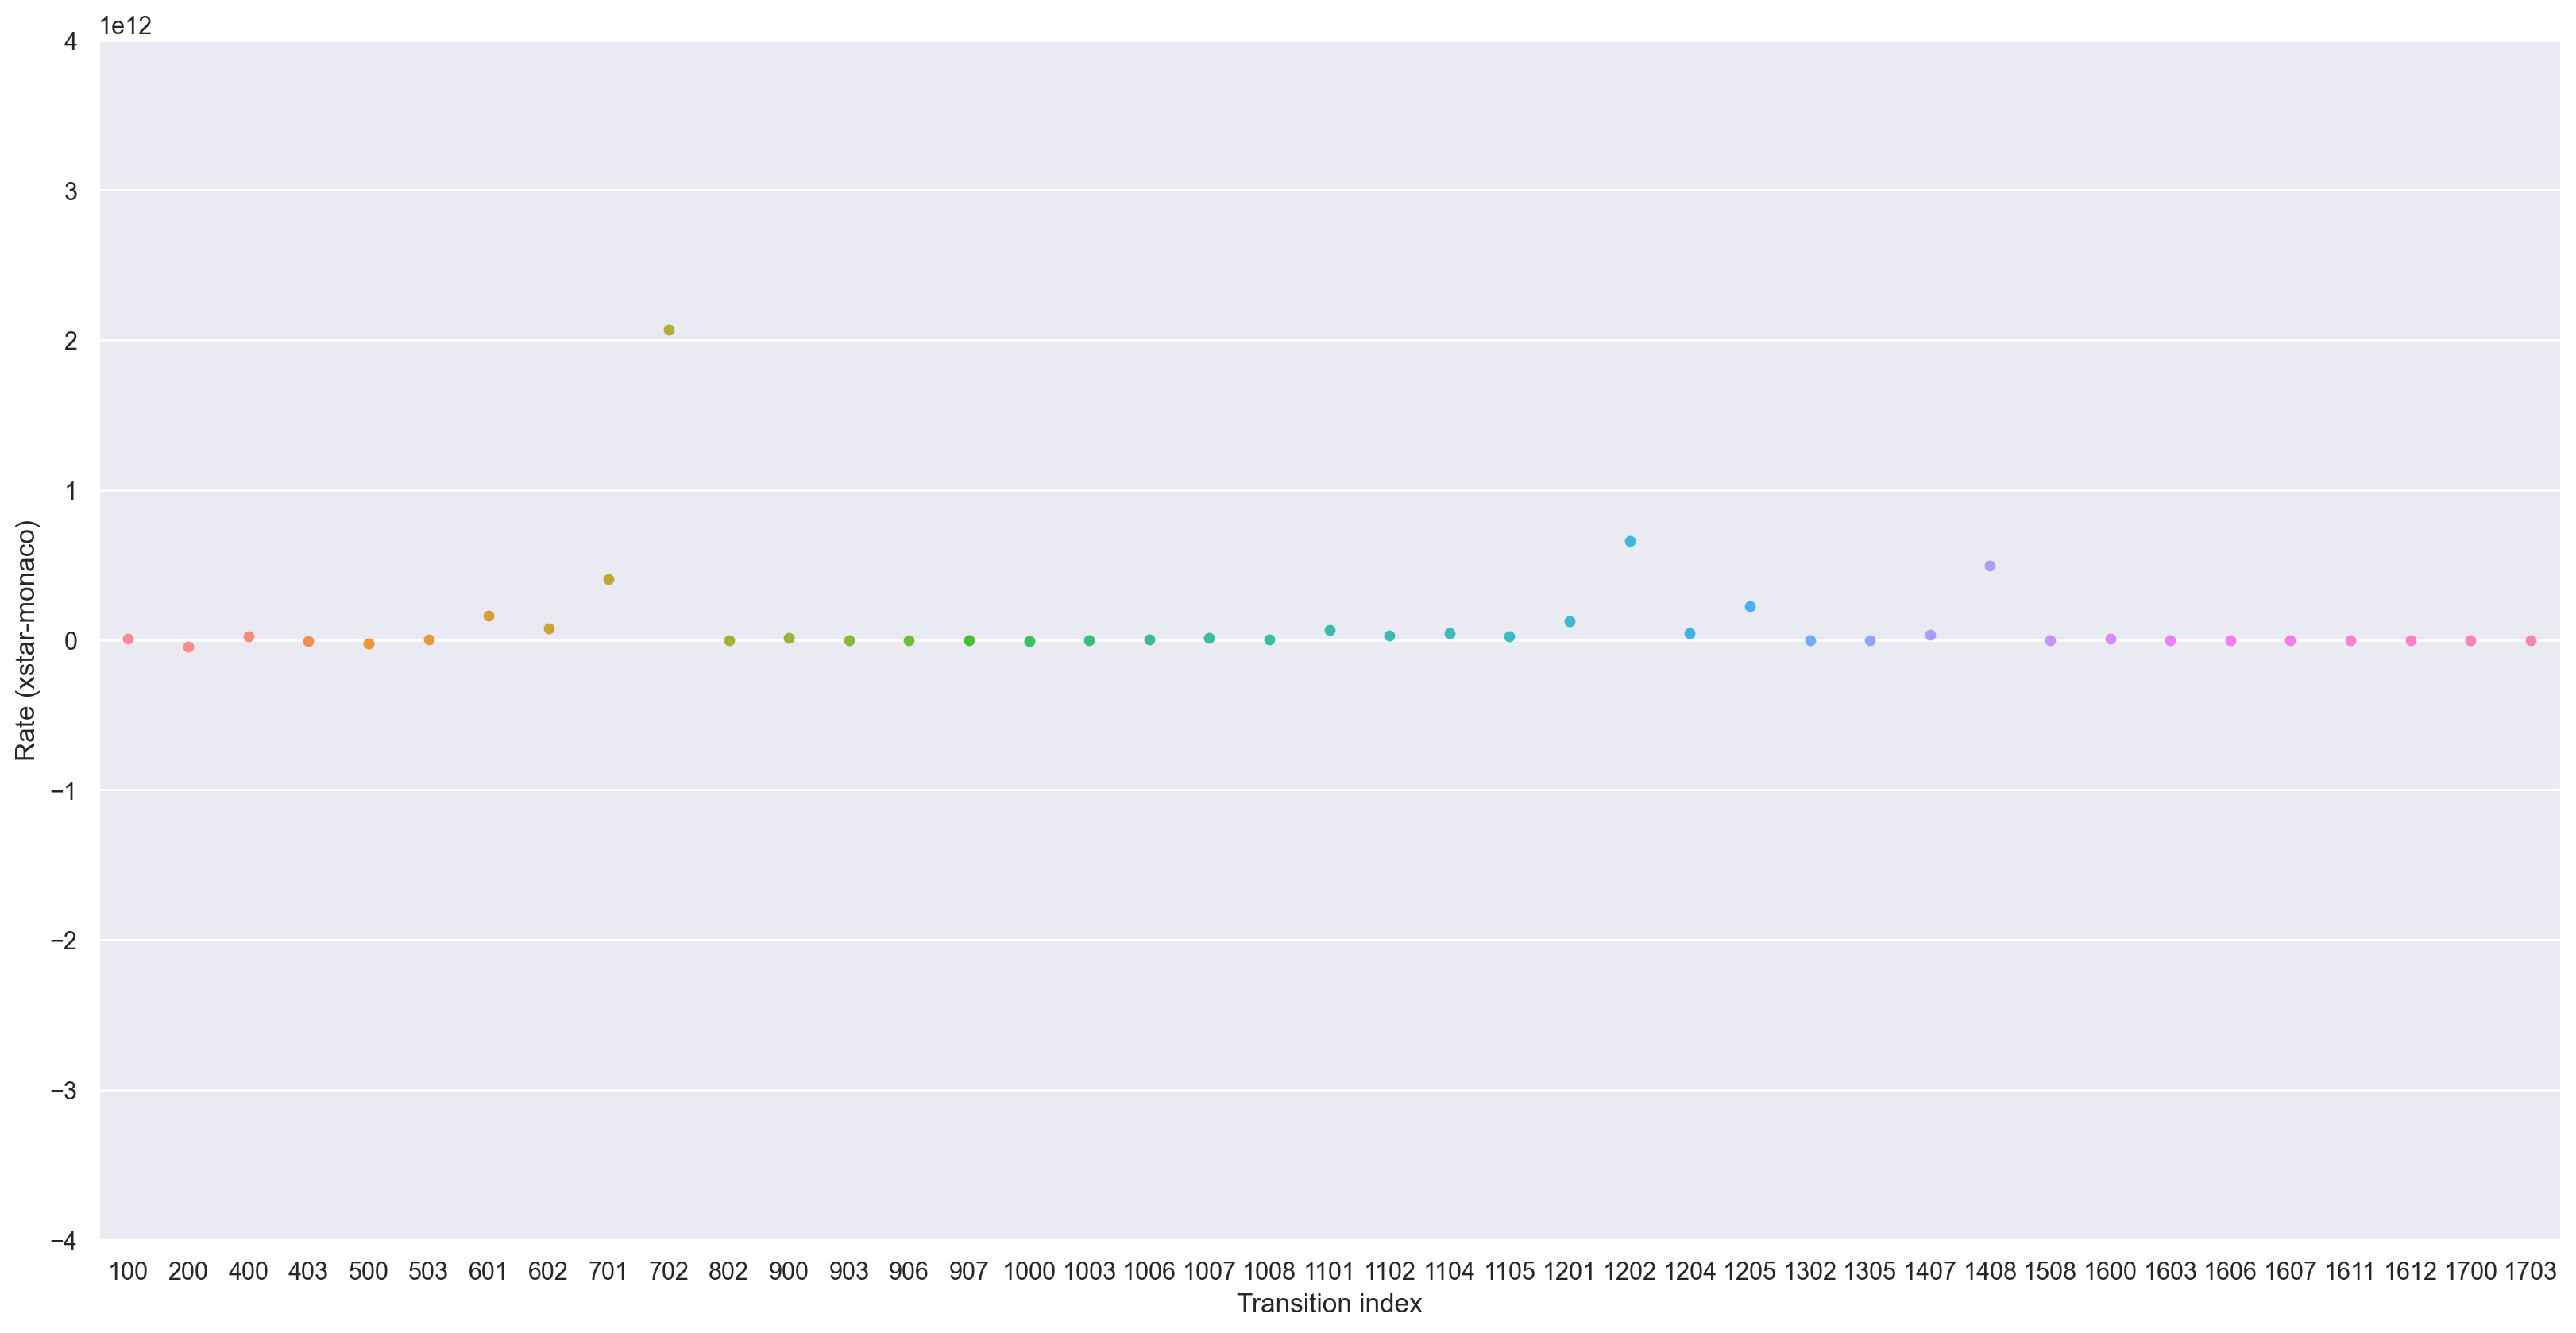

In [22]:
fi = figure(figsize=(20,10),dpi=200)
axis       ([0e+0,3e+3,-4e+12,+4e+12])
swarmplot  (x=Si01_Transition_Index[:41], y=Si01_Transition_Rate[:41])
xlabel     ("Transition index")
ylabel     ("Rate (xstar-monaco)")

Text(0, 0.5, 'Rate (xstar-monaco)')

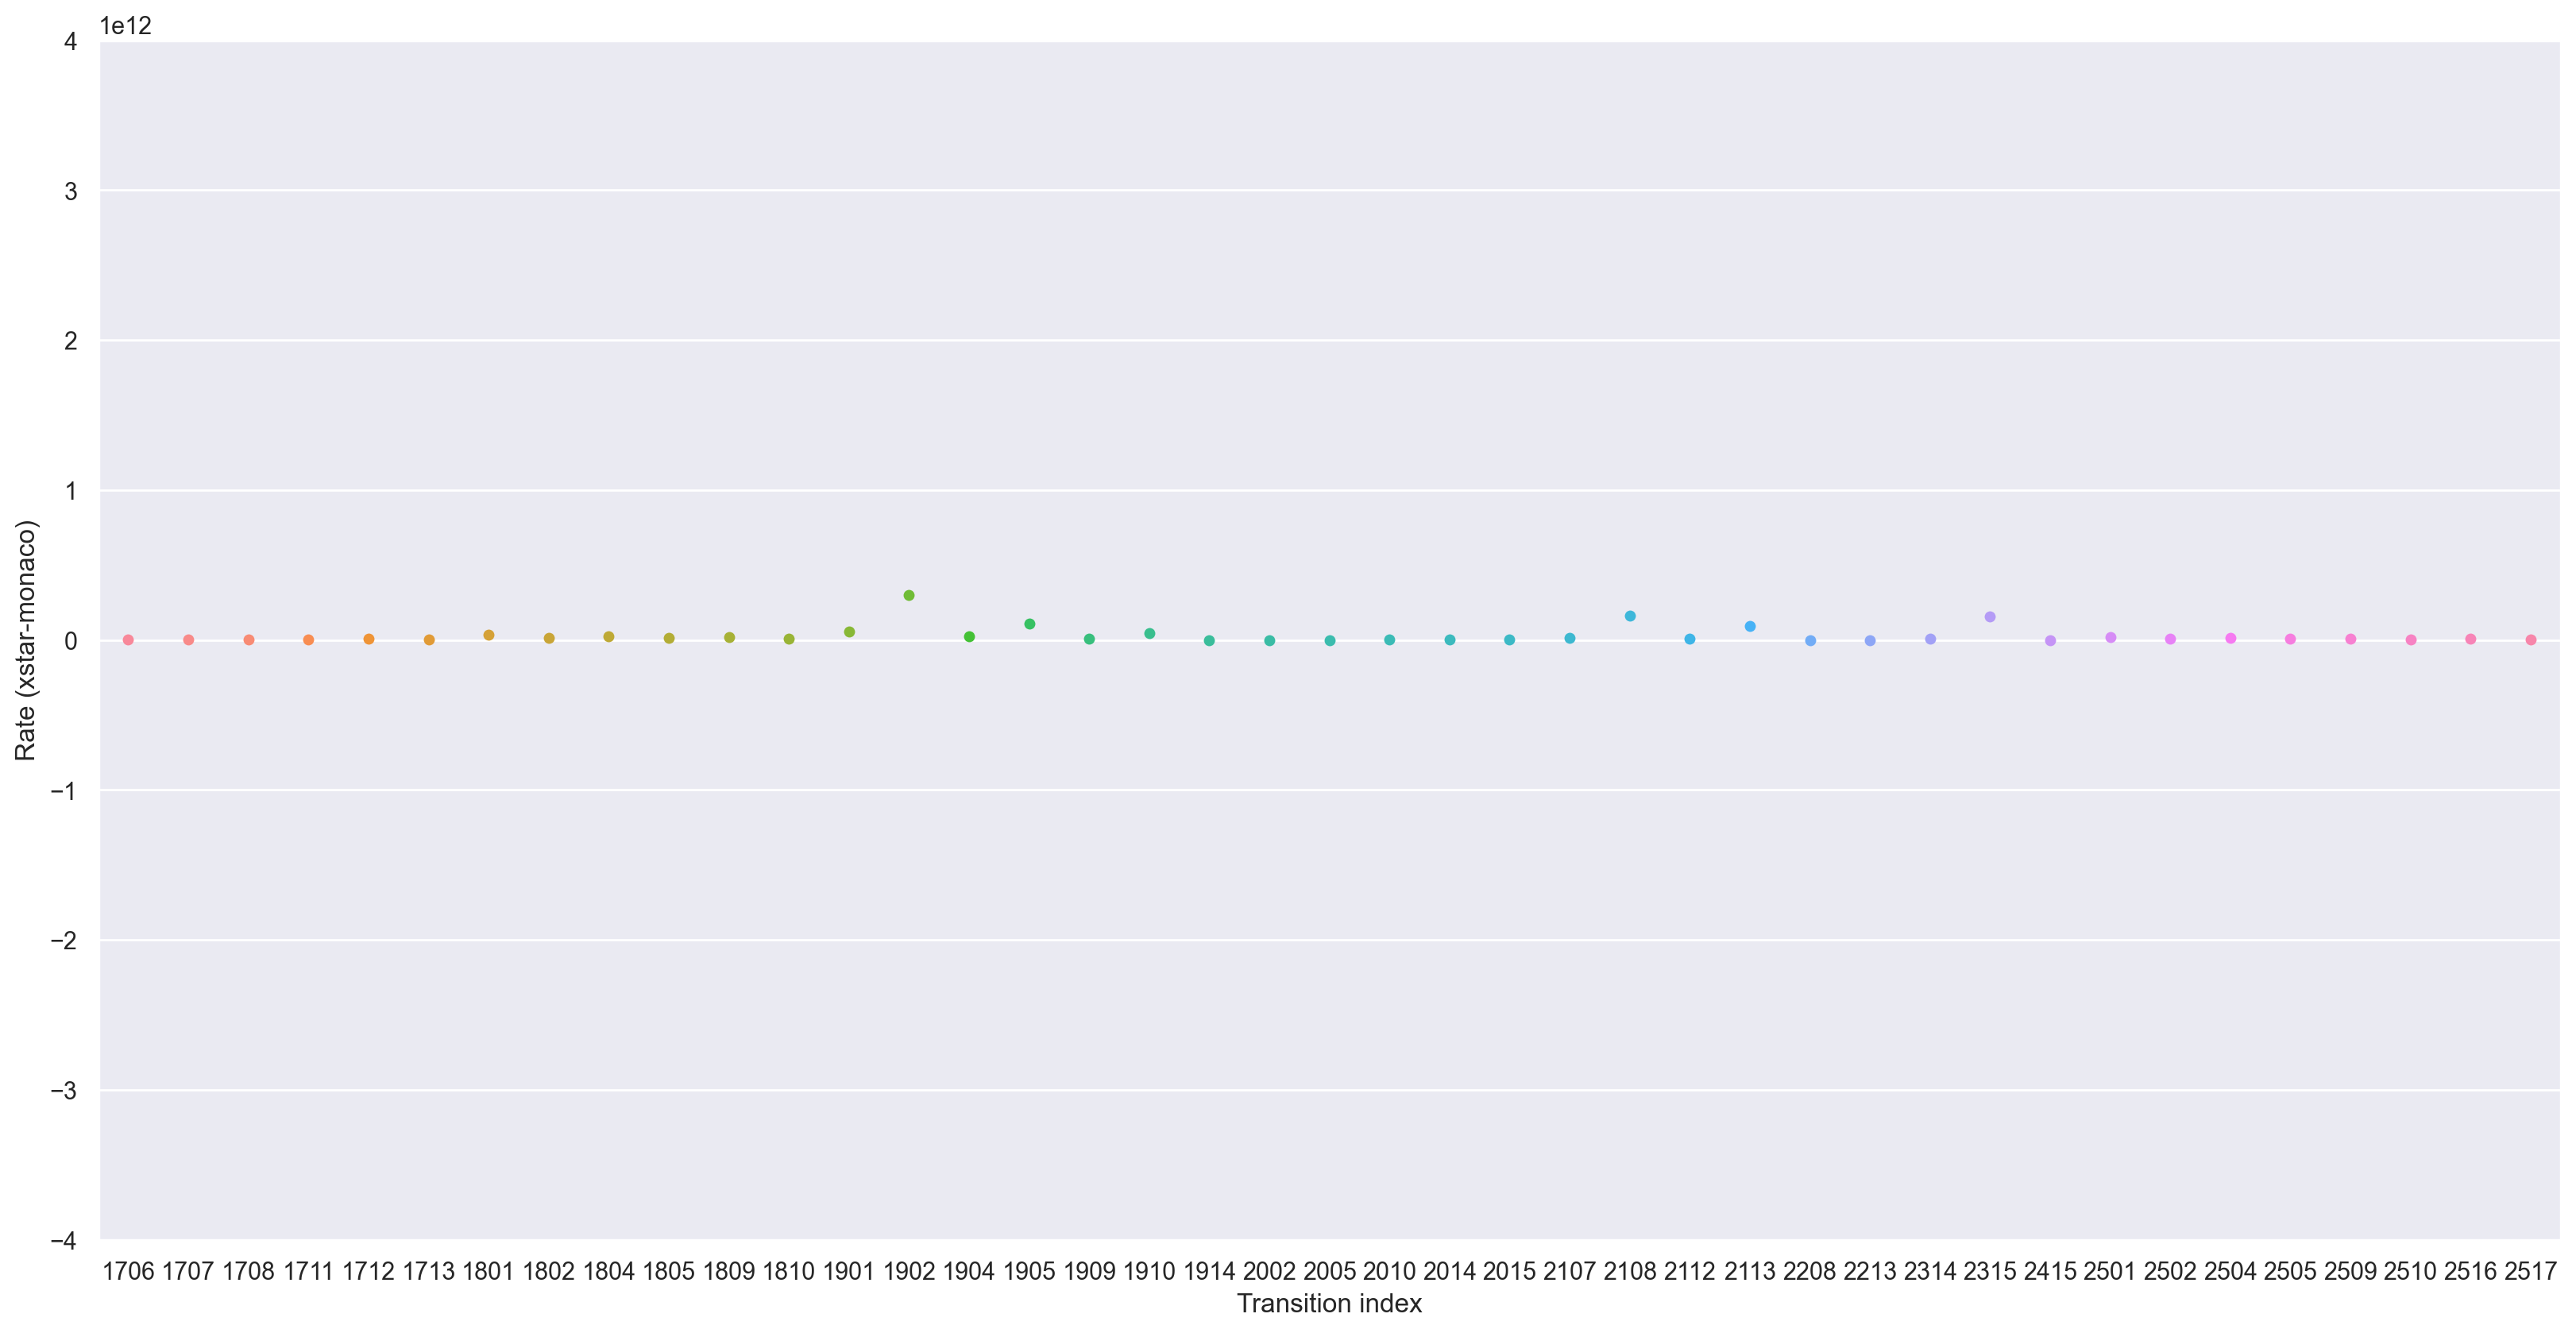

In [23]:
fi = figure(figsize=(20,10),dpi=200)
axis       ([0e+0,3e+3,-4e+12,+4e+12])
swarmplot  (x=Si01_Transition_Index[41:], y=Si01_Transition_Rate[41:])
xlabel     ("Transition index")
ylabel     ("Rate (xstar-monaco)")

# Si02 Transition

## Load Xstar Data

In [24]:
Si02_Transition_xstar = read_csv("/Users/tanimoto/github/atomicdatabase/xstar_database/Si/Si02.tr", names=["Initial Level", "Initial Level Weight", "Final Level", "Final Level Weight", "Energy", "Strength", "Rate"], sep="\t")
Si02_Transition_xstar = Si02_Transition_xstar.drop(columns=["Initial Level Weight", "Final Level Weight"])
Si02_Transition_xstar

,Initial Level,Final Level,Energy,Strength,Rate
0,1,0,1839.36100,0.000,3.600000e+05
1,2,0,1853.47100,0.000,1.371500e+08
2,2,1,14.11078,0.155,1.854000e+08
3,3,0,1853.69300,0.000,1.371500e+08
4,3,1,14.33209,0.155,1.854000e+08
...,...,...,...,...,...
207,55,6,1969.62700,0.000,3.680000e+14
208,56,2,1974.74800,0.000,5.833000e+12
209,56,3,1974.52700,0.000,5.833000e+12
210,56,4,1973.64100,0.000,5.833000e+12


## Load Monaco Data

In [25]:
Initial_Level        = []
Initial_Level_Weight = []
Final_Level          = []
Final_Level_Weight   = []
Energy               = []
Strength             = []
Rate                 = []

with open("/Users/tanimoto/github/atomicdatabase/monaco_database/Si/Si02.tr") as file:
    for line in file.readlines():
        line = line.split()
        if line[0] in Si02_Translation.keys() and line[2] in Si02_Translation.values():
            Initial_Level.append(int(Si02_Translation[line[0]]))
            Final_Level.append(int(Si02_Translation[line[2]]))
            Energy.append(float(line[4]))
            Strength.append(float(line[5]))
            Rate.append(float(line[6]))

Si02_Transition_monaco = DataFrame({"Initial Level":Initial_Level, "Final Level":Final_Level, "Energy":Energy, "Strength":Strength, "Rate":Rate})
Si02_Transition_monaco = Si02_Transition_monaco.sort_values(["Initial Level", "Final Level"]).reset_index(drop=True)
Si02_Transition_monaco

,Initial Level,Final Level,Energy,Strength,Rate
0,1,0,1839.435000,6.679080e-09,3.268689e+05
1,2,1,14.113820,6.009970e-03,1.558447e+08
2,2,1,1984.210000,4.570210e-02,2.342298e+13
3,4,0,1854.649000,1.267005e-06,3.782172e+07
4,4,1,15.214210,3.254385e-02,1.961229e+08
...,...,...,...,...,...
1260,52,2,1983.412000,2.739309e-01,1.558673e+13
1261,52,4,10.344200,5.268059e-09,4.076641e+01
1262,52,4,1982.311000,6.848756e-02,1.946316e+13
1263,54,1,15.542300,3.293246e-11,1.035584e+00
